In [1]:
from stopping_analysis import StoppingPowerAnalysis

import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/small_unitcell/"
# data_directory = "/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/larger_unitcell/"

In [3]:
analysis = StoppingPowerAnalysis(data_directory)

/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/data/small_unitcell/
{
    "40 keV": [
        "aluminium_fcc_ek40k_step10.gpw",
        "aluminium_fcc_ek40k_step20.gpw",
        "aluminium_fcc_ek40k_step30.gpw",
        "aluminium_fcc_ek40k_step40.gpw",
        "aluminium_fcc_ek40k_step50.gpw",
        "aluminium_fcc_ek40k_step60.gpw",
        "aluminium_fcc_ek40k_step70.gpw",
        "aluminium_fcc_ek40k_step80.gpw",
        "aluminium_fcc_ek40k_step90.gpw"
    ],
    "20 keV": [
        "aluminium_fcc_ek20k_step10.gpw",
        "aluminium_fcc_ek20k_step20.gpw",
        "aluminium_fcc_ek20k_step30.gpw",
        "aluminium_fcc_ek20k_step40.gpw",
        "aluminium_fcc_ek20k_step50.gpw",
        "aluminium_fcc_ek20k_step60.gpw",
        "aluminium_fcc_ek20k_step70.gpw",
        "aluminium_fcc_ek20k_step80.gpw",
        "aluminium_fcc_ek20k_step90.gpw"
    ]
}


/Users/brynlloyd/Developer/Coding/Python/dft/gpaw/my_own_stopping/env/lib/python3.9/site-packages/gpaw/wavefunctions/base.py:572: ComplexWarning: Casting complex values to real discards the imaginary part
  kpt.projections.matrix.array[:] = P_nI


[np.float64(7.213484066225499), np.float64(9.426629763477125), np.float64(11.639838366667236), np.float64(13.852924197849177), np.float64(16.064821138040227), np.float64(18.275092656587304), np.float64(20.485041734406384), np.float64(22.69511069274247), np.float64(24.90504032104717)]
[19.98906911 19.98904668 19.98945132 19.98253931 19.95127777 19.9288584
 19.93271043 19.93197853 19.93027597]


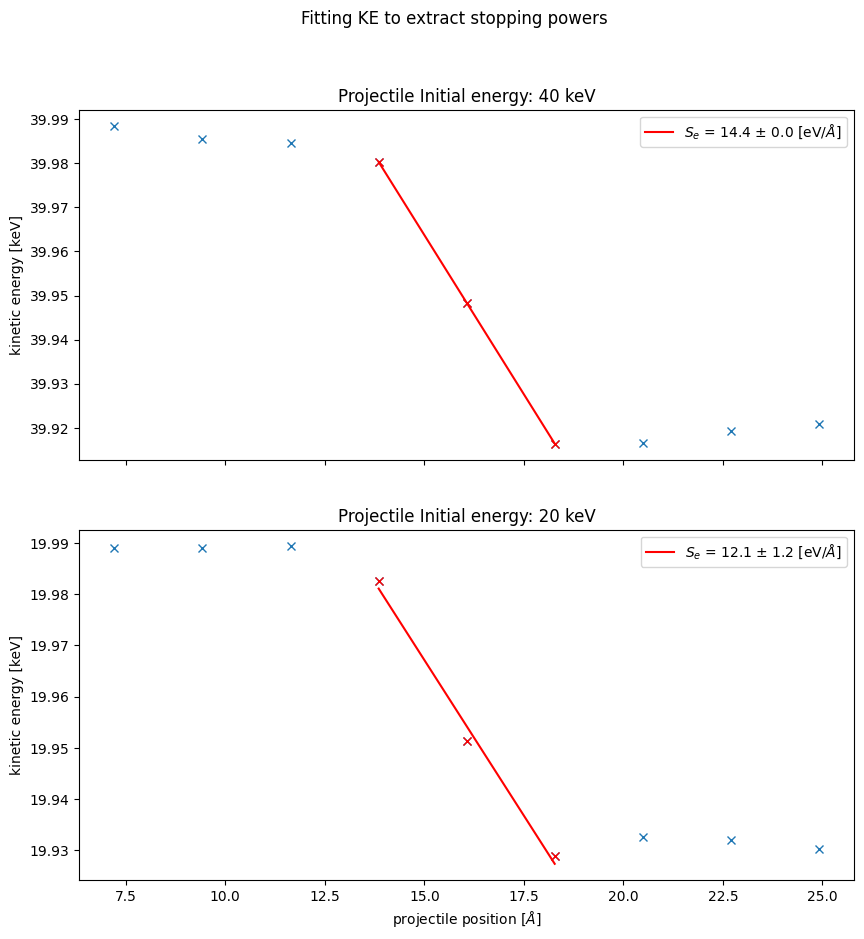

In [4]:
analysis.plot_kinetic_energies()

In [68]:
def calculate_r2(x, y, y_fit):
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else -np.inf
    return r2


def sliding_fit(x,y, min_window_size, max_window_size = None):
    if max_window_size == None:
        max_window_size = len(x)


    best_r2 = -np.inf
    best_start = 0
    best_fit = None
    best_cov = None
    best_x = None
    best_y = None


    for window_size in range(min_window_size, len(x)):
        for i in range(len(x) - window_size):
            x_window = x[i : i+window_size]
            y_window = y[i : i+window_size]

            fit, cov = np.polyfit(x_window, y_window, 1, cov=True)
            pfit = np.poly1d(fit)
            y_fit = pfit(x_window)

            r2 = calculate_r2(x_window, y_window, y_fit)


            if r2 > best_r2:
                best_r2 = r2
                best_start = i
                best_fit = fit
                best_cov = cov
                best_x = x_window
                best_y = y_window

    return best_fit, best_cov, best_x, best_y
